# Regressão Polinomial
## Previsão do Consumo de Combustível em Função da Velocidade

Neste notebook, exploraremos o caso clássico em que a relação entre as variáveis **não é uma reta**, mas pode ser bem aproximada por um **polinômio**.

Trabalharemos com a relação entre a **velocidade de um veículo (km/h)** e seu **consumo de combustível (km/L)**:

- Em velocidades muito baixas, o motor opera fora da faixa de eficiência → consumo ruim.
- Em velocidades intermediárias (~70–80 km/h), o consumo é o melhor possível.
- Em velocidades muito altas, a resistência do ar cresce rapidamente → consumo cai novamente.

A relação tem o formato de uma **parábola** — um caso ideal para a regressão polinomial.

## Conceito: Regressão Polinomial

A regressão polinomial é uma extensão direta da regressão linear. A ideia é simples: a relação entre $x$ e $y$ pode ser modelada por um polinômio de grau $n$:

$$y = b_0 + b_1 x + b_2 x^2 + b_3 x^3 + \dots + b_n x^n$$

Apesar do nome, ela é tratada como **regressão linear nos coeficientes** — basta criar novas colunas com $x^2, x^3, \dots$ e usar o mesmo `LinearRegression`.

Atenção a dois cuidados práticos:
1. **Grau muito baixo** → o modelo não captura a curva (subajuste).
2. **Grau muito alto** → o modelo decora o ruído dos dados (sobreajuste).

## 1. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')

## 2. Carregamento dos Dados

O dataset contém 180 medições de consumo de um veículo em diferentes velocidades médias de viagem.

In [2]:
df = pd.read_csv('dados_consumo_veiculo.csv')
print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head(10)

Dimensões: 180 linhas × 2 colunas


,velocidade_kmh,consumo_km_por_litro
0,20.88,5.24
1,22.59,5.44
2,22.73,6.28
3,22.74,7.49
4,23.70,6.02
5,24.49,5.70
6,24.99,6.33
7,25.26,6.11
8,25.39,7.04
9,27.00,8.14


In [3]:
df.describe().round(2)

,velocidade_kmh,consumo_km_por_litro
count,180.00,180.00
mean,79.20,12.01
std,33.69,3.86
min,20.88,2.27
25%,51.60,9.70
50%,77.48,13.02
75%,107.77,15.11
max,139.09,17.62


## 3. Visualização dos Dados

Antes de modelar, é fundamental visualizar a relação para escolher uma forma funcional adequada.

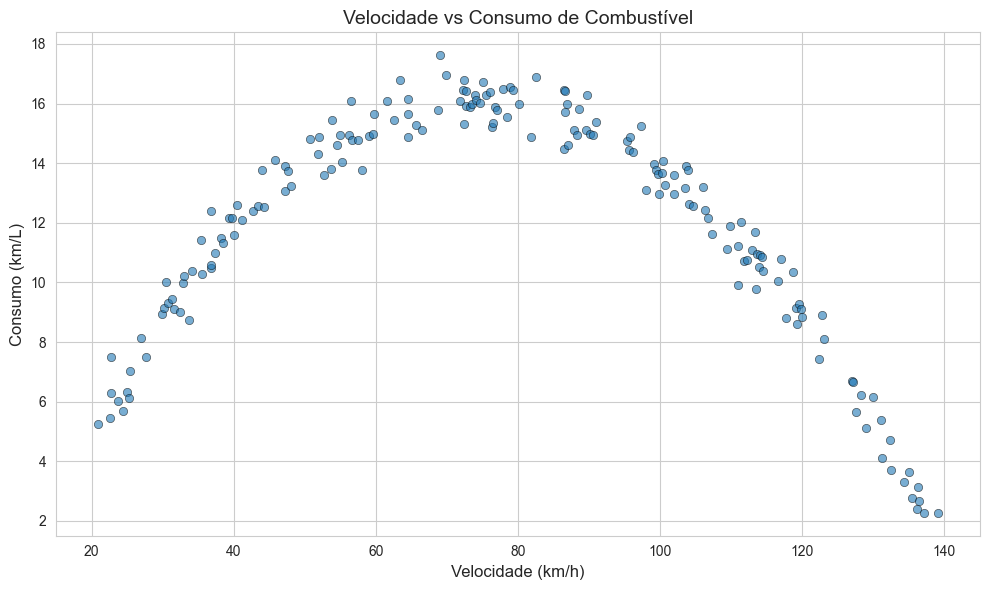

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(df['velocidade_kmh'], df['consumo_km_por_litro'],
            alpha=0.6, edgecolors='k', linewidths=0.5)
plt.xlabel('Velocidade (km/h)', fontsize=12)
plt.ylabel('Consumo (km/L)', fontsize=12)
plt.title('Velocidade vs Consumo de Combustível', fontsize=14)
plt.tight_layout()
plt.show()

Observe que a nuvem de pontos forma uma **curva côncava** — uma reta não conseguiria ajustar bem. Vamos confirmar isso.

## 4. Tentativa Inicial: Regressão Linear Simples

Para deixar claro o problema, ajustamos primeiro uma reta.

In [5]:
X = df[['velocidade_kmh']]
y = df['consumo_km_por_litro']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Regressão linear simples
modelo_linear = LinearRegression()
modelo_linear.fit(X_treino, y_treino)
y_pred_linear = modelo_linear.predict(X_teste)

r2_linear = r2_score(y_teste, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_teste, y_pred_linear))
print(f'Regressão Linear — R²: {r2_linear:.4f} | RMSE: {rmse_linear:.4f}')

Regressão Linear — R²: 0.0608 | RMSE: 3.1433


/Users/fernando.come/Documents/Alura/Regressão_NãoLinear/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


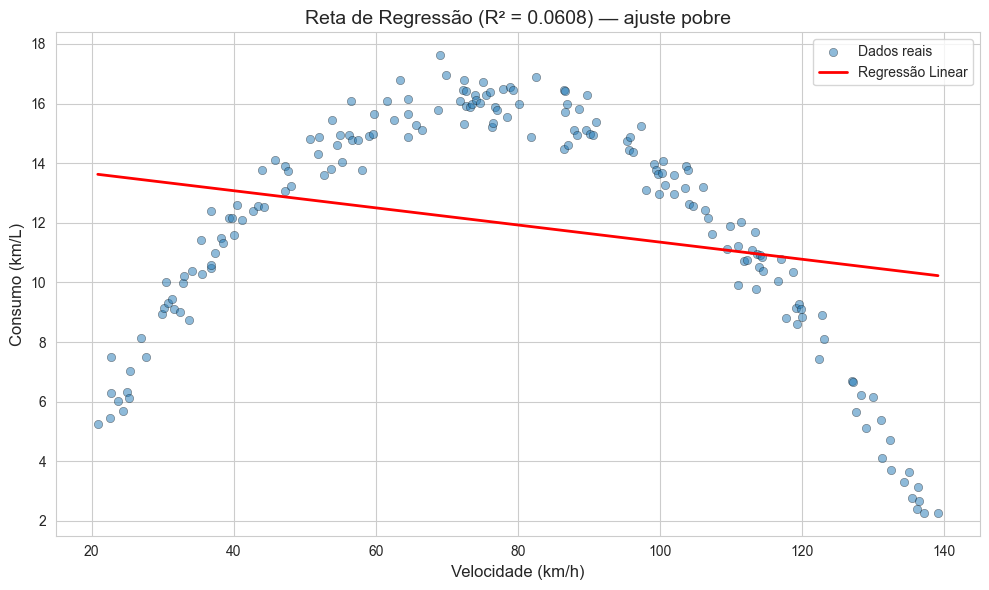

In [6]:
# Plot para visualizar o ajuste linear
x_grid = np.linspace(df['velocidade_kmh'].min(), df['velocidade_kmh'].max(), 200).reshape(-1, 1)
y_grid_linear = modelo_linear.predict(x_grid)

plt.figure(figsize=(10, 6))
plt.scatter(df['velocidade_kmh'], df['consumo_km_por_litro'],
            alpha=0.5, label='Dados reais', edgecolors='k', linewidths=0.4)
plt.plot(x_grid, y_grid_linear, color='red', linewidth=2, label='Regressão Linear')
plt.xlabel('Velocidade (km/h)', fontsize=12)
plt.ylabel('Consumo (km/L)', fontsize=12)
plt.title(f'Reta de Regressão (R² = {r2_linear:.4f}) — ajuste pobre', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

Como esperado, a reta não acompanha a curvatura. Vamos para o passo a passo da **regressão polinomial**.

## 5. Regressão Polinomial de Grau 2

Geramos features polinomiais até grau 2: para cada $x$ teremos as colunas $[1, x, x^2]$. Em seguida usamos uma `LinearRegression` normal sobre essas colunas.

In [7]:
# Demonstração explícita do que o PolynomialFeatures faz
poly2 = PolynomialFeatures(degree=2, include_bias=False)
exemplo = poly2.fit_transform([[80]])
print('Para velocidade = 80 km/h, as features geradas são:')
print(f'  [x, x²] = {exemplo[0]}')
print(f'  Nomes:    {poly2.get_feature_names_out(["velocidade"])}')

Para velocidade = 80 km/h, as features geradas são:
  [x, x²] = [  80. 6400.]
  Nomes:    ['velocidade' 'velocidade^2']


In [8]:
# Pipeline: transforma os dados em polinômio + ajusta regressão linear
modelo_poly2 = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)
modelo_poly2.fit(X_treino, y_treino)

y_pred_poly2 = modelo_poly2.predict(X_teste)

# Coeficientes encontrados
linear_step = modelo_poly2.named_steps['linearregression']
b0 = linear_step.intercept_
b1, b2 = linear_step.coef_
print(f'Equação ajustada: y = {b0:.4f} + {b1:.4f} x + {b2:.6f} x²\n')

r2_poly2 = r2_score(y_teste, y_pred_poly2)
rmse_poly2 = np.sqrt(mean_squared_error(y_teste, y_pred_poly2))
print(f'Polinomial grau 2 — R²: {r2_poly2:.4f} | RMSE: {rmse_poly2:.4f}')

Equação ajustada: y = -4.2703 + 0.5435 x + -0.003617 x²

Polinomial grau 2 — R²: 0.9697 | RMSE: 0.5646


## 6. Visualização do Ajuste Polinomial

/Users/fernando.come/Documents/Alura/Regressão_NãoLinear/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


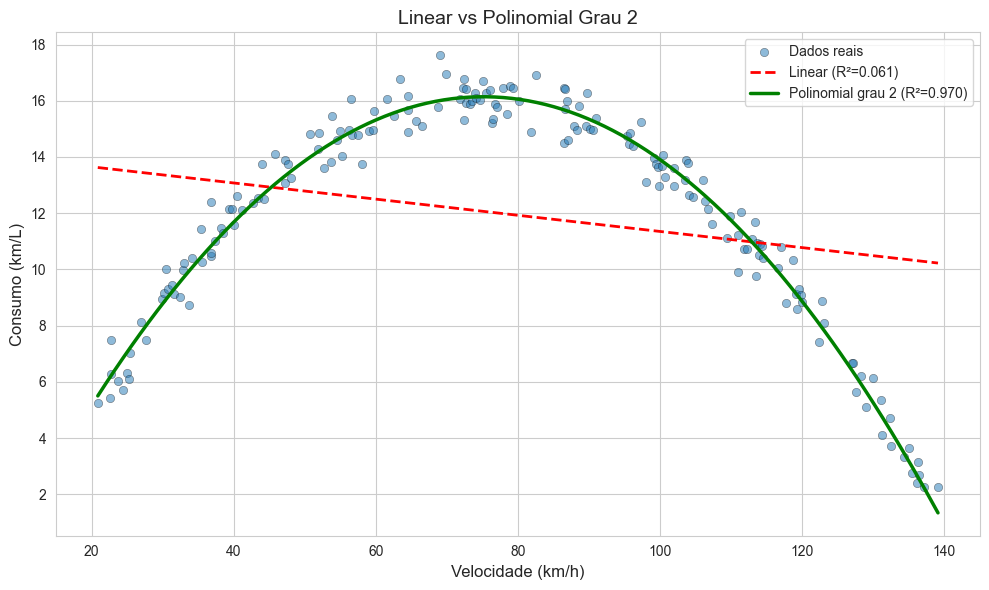

In [9]:
y_grid_poly2 = modelo_poly2.predict(x_grid)

plt.figure(figsize=(10, 6))
plt.scatter(df['velocidade_kmh'], df['consumo_km_por_litro'],
            alpha=0.5, label='Dados reais', edgecolors='k', linewidths=0.4)
plt.plot(x_grid, y_grid_linear, color='red', linewidth=2, linestyle='--',
         label=f'Linear (R²={r2_linear:.3f})')
plt.plot(x_grid, y_grid_poly2, color='green', linewidth=2.5,
         label=f'Polinomial grau 2 (R²={r2_poly2:.3f})')
plt.xlabel('Velocidade (km/h)', fontsize=12)
plt.ylabel('Consumo (km/L)', fontsize=12)
plt.title('Linear vs Polinomial Grau 2', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

A parábola se encaixa muito melhor nos dados.

## 7. Comparação entre Diferentes Graus

E se tentarmos graus maiores? Há sempre um ponto em que aumentar o grau **deixa de ajudar** e começa a prejudicar (sobreajuste). Vamos comparar diversos graus.

In [10]:
graus = [1, 2, 3, 4, 6, 10, 15]

resultados_grau = []
for g in graus:
    modelo_g = make_pipeline(
        PolynomialFeatures(degree=g, include_bias=False),
        LinearRegression()
    )
    modelo_g.fit(X_treino, y_treino)

    r2_treino = r2_score(y_treino, modelo_g.predict(X_treino))
    r2_teste = r2_score(y_teste, modelo_g.predict(X_teste))
    rmse_teste = np.sqrt(mean_squared_error(y_teste, modelo_g.predict(X_teste)))
    resultados_grau.append({
        'Grau': g,
        'R² Treino': r2_treino,
        'R² Teste': r2_teste,
        'RMSE Teste': rmse_teste
    })

df_graus = pd.DataFrame(resultados_grau)
df_graus.round(4)

,Grau,R² Treino,R² Teste,RMSE Teste
0,1,0.0594,0.0608,3.1433
1,2,0.9766,0.9697,0.5646
2,3,0.9776,0.9698,0.5637
3,4,0.9776,0.9707,0.5552
4,6,0.9776,0.9708,0.5541
5,10,0.9140,0.9215,0.9086
6,15,0.7257,0.6938,1.7947


**Como ler a tabela:**
- O **R² no treino** quase sempre cresce com o grau (o modelo se adapta cada vez mais aos dados de treino).
- O **R² no teste** é o que importa: ele captura a capacidade de generalizar.
- Quando o R² de teste começa a cair (e o RMSE a subir) à medida que o grau cresce, é o sinal do **sobreajuste**.

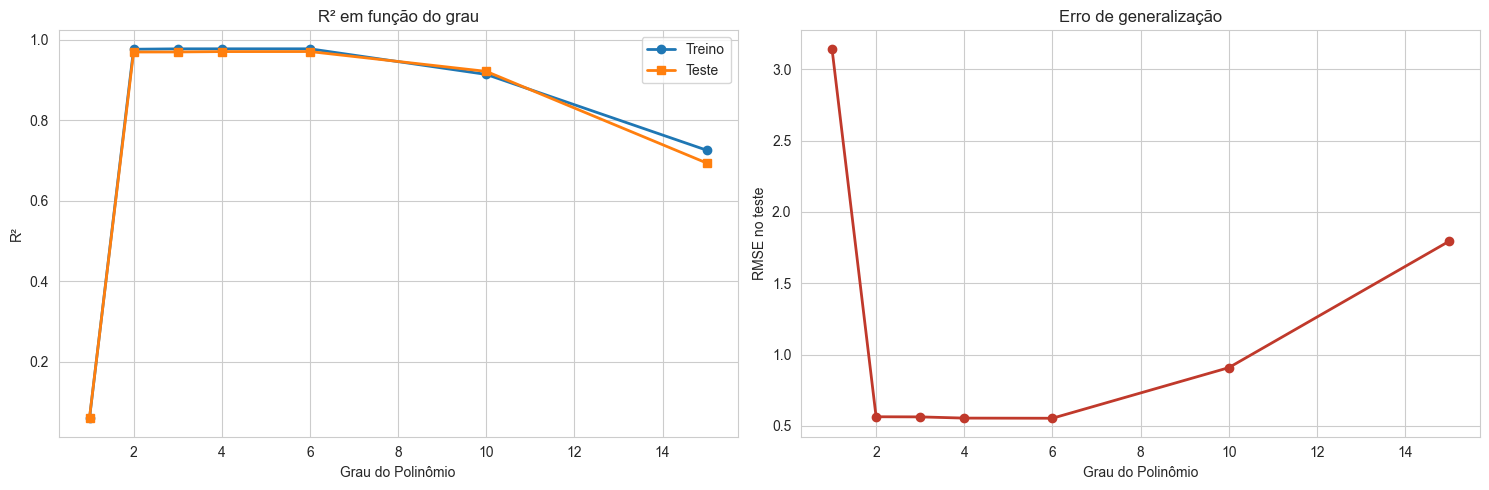

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(df_graus['Grau'], df_graus['R² Treino'], marker='o', label='Treino', linewidth=2)
axes[0].plot(df_graus['Grau'], df_graus['R² Teste'],  marker='s', label='Teste',  linewidth=2)
axes[0].set_xlabel('Grau do Polinômio')
axes[0].set_ylabel('R²')
axes[0].set_title('R² em função do grau')
axes[0].legend()

axes[1].plot(df_graus['Grau'], df_graus['RMSE Teste'], marker='o', color='#c0392b', linewidth=2)
axes[1].set_xlabel('Grau do Polinômio')
axes[1].set_ylabel('RMSE no teste')
axes[1].set_title('Erro de generalização')

plt.tight_layout()
plt.show()

## 8. Visualização: Subajuste vs Bom Ajuste vs Sobreajuste

/Users/fernando.come/Documents/Alura/Regressão_NãoLinear/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/Users/fernando.come/Documents/Alura/Regressão_NãoLinear/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/Users/fernando.come/Documents/Alura/Regressão_NãoLinear/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


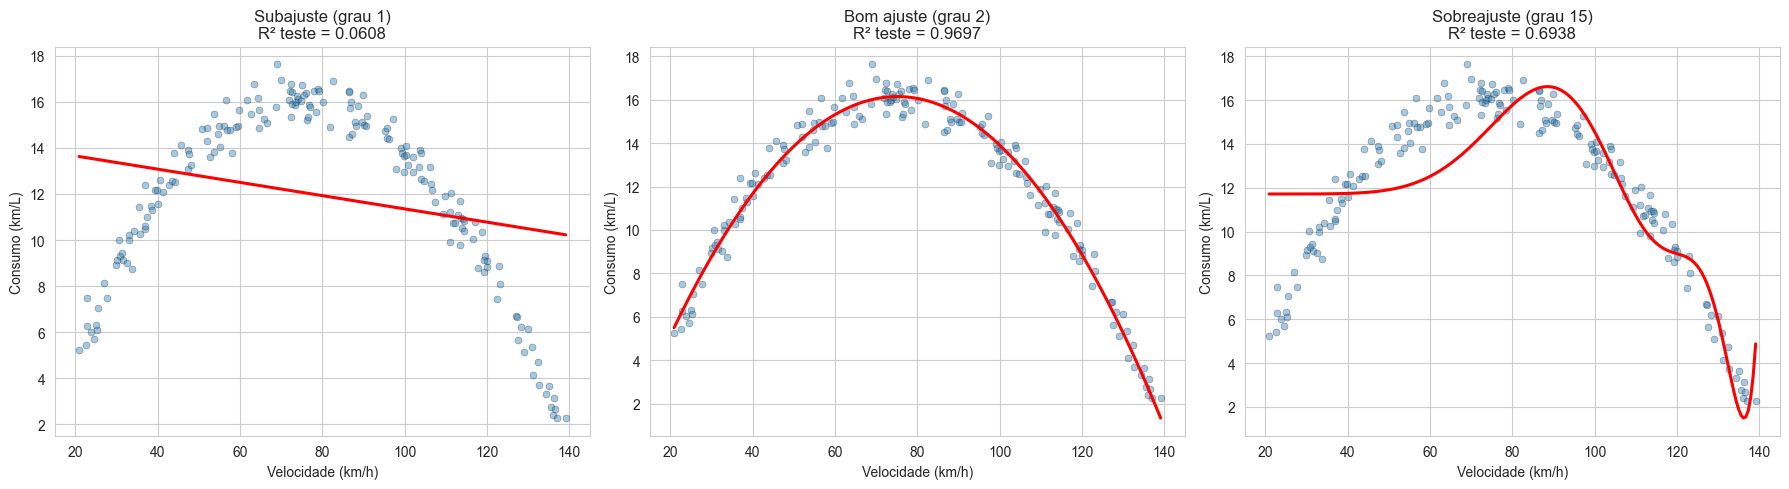

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
graus_plot = [1, 2, 15]
titulos = ['Subajuste (grau 1)', 'Bom ajuste (grau 2)', 'Sobreajuste (grau 15)']

for ax, g, titulo in zip(axes, graus_plot, titulos):
    modelo_g = make_pipeline(
        PolynomialFeatures(degree=g, include_bias=False),
        LinearRegression()
    )
    modelo_g.fit(X_treino, y_treino)
    y_grid_g = modelo_g.predict(x_grid)

    ax.scatter(df['velocidade_kmh'], df['consumo_km_por_litro'],
               alpha=0.4, edgecolors='k', linewidths=0.4, s=25)
    ax.plot(x_grid, y_grid_g, color='red', linewidth=2.2)
    r2_g = r2_score(y_teste, modelo_g.predict(X_teste))
    ax.set_title(f'{titulo}\nR² teste = {r2_g:.4f}')
    ax.set_xlabel('Velocidade (km/h)')
    ax.set_ylabel('Consumo (km/L)')

plt.tight_layout()
plt.show()

Note como o polinômio de grau 15 cria oscilações estranhas nas bordas — isso é um **sintoma clássico de sobreajuste**.

## 9. Selecionando o Melhor Grau

Pela análise acima, o grau **2** é a melhor escolha: ajusta bem a curvatura sem complicar demais o modelo. Vamos consolidar esse modelo final.

In [13]:
modelo_final = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)
modelo_final.fit(X_treino, y_treino)
y_pred_final = modelo_final.predict(X_teste)

r2 = r2_score(y_teste, y_pred_final)
mae = mean_absolute_error(y_teste, y_pred_final)
mse = mean_squared_error(y_teste, y_pred_final)
rmse = np.sqrt(mse)

print('╔═══════════════════════════════════════╗')
print('║   MÉTRICAS — POLINÔMIO GRAU 2         ║')
print('╠═══════════════════════════════════════╣')
print(f'║  R²:    {r2:.4f}                        ║')
print(f'║  MAE:   {mae:.4f} km/L                  ║')
print(f'║  MSE:   {mse:.4f}                       ║')
print(f'║  RMSE:  {rmse:.4f} km/L                  ║')
print('╚═══════════════════════════════════════╝')

╔═══════════════════════════════════════╗
║   MÉTRICAS — POLINÔMIO GRAU 2         ║
╠═══════════════════════════════════════╣
║  R²:    0.9697                        ║
║  MAE:   0.4375 km/L                  ║
║  MSE:   0.3187                       ║
║  RMSE:  0.5646 km/L                  ║
╚═══════════════════════════════════════╝


## 10. Análise de Resíduos

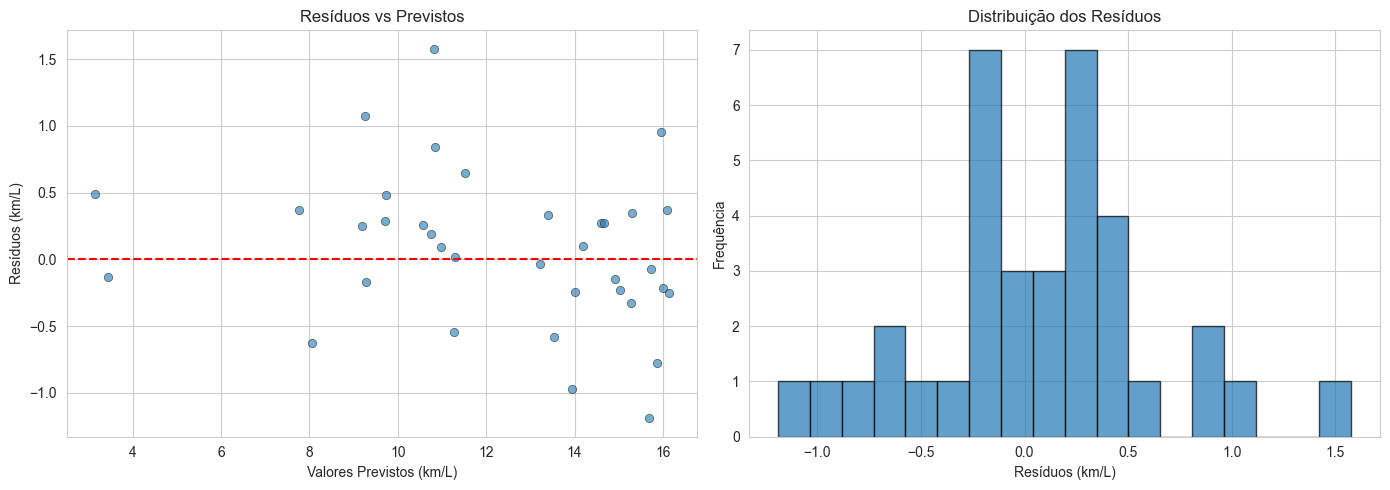

In [14]:
residuos = y_teste - y_pred_final

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_final, residuos, alpha=0.6, edgecolors='k', linewidths=0.5)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Valores Previstos (km/L)')
axes[0].set_ylabel('Resíduos (km/L)')
axes[0].set_title('Resíduos vs Previstos')

axes[1].hist(residuos, bins=18, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Resíduos (km/L)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição dos Resíduos')

plt.tight_layout()
plt.show()

Os resíduos estão razoavelmente distribuídos em torno de zero, sem padrão visível — sinal de que o grau 2 capturou bem a estrutura dos dados.

## 11. Encontrando a Velocidade de Maior Eficiência

Como o ajuste é uma parábola côncava ($b_2 < 0$), o ponto de máximo do consumo (km/L) ocorre em:

$$x^* = -\frac{b_1}{2 b_2}$$

In [15]:
linear_step = modelo_final.named_steps['linearregression']
b0 = linear_step.intercept_
b1, b2 = linear_step.coef_

velocidade_otima = -b1 / (2 * b2)
consumo_otimo = b0 + b1 * velocidade_otima + b2 * velocidade_otima ** 2

print(f'Velocidade que maximiza o consumo (km/L): {velocidade_otima:.2f} km/h')
print(f'Consumo estimado nessa velocidade:        {consumo_otimo:.2f} km/L')

Velocidade que maximiza o consumo (km/L): 75.12 km/h
Consumo estimado nessa velocidade:        16.14 km/L


## 12. Previsão para Novas Velocidades

In [16]:
novas_velocidades = pd.DataFrame({'velocidade_kmh': [30, 50, 70, 90, 110, 130]})
previsoes = modelo_final.predict(novas_velocidades)

for v, c in zip(novas_velocidades['velocidade_kmh'], previsoes):
    print(f'Velocidade: {v:>3d} km/h  →  Consumo previsto: {c:.2f} km/L')

Velocidade:  30 km/h  →  Consumo previsto: 8.78 km/L
Velocidade:  50 km/h  →  Consumo previsto: 13.86 km/L
Velocidade:  70 km/h  →  Consumo previsto: 16.05 km/L
Velocidade:  90 km/h  →  Consumo previsto: 15.34 km/L
Velocidade: 110 km/h  →  Consumo previsto: 11.74 km/L
Velocidade: 130 km/h  →  Consumo previsto: 5.25 km/L


## Conclusão

- A relação entre velocidade e consumo é **claramente não linear**, e tentar ajustar uma reta dá um R² baixo.
- Um simples polinômio de grau 2 já captura a curvatura e atinge ótimo desempenho.
- Aumentar o grau além do necessário leva ao **sobreajuste**: o modelo "decora" os dados de treino e perde poder de generalização.
- Sempre comparar treino e teste é essencial para escolher um grau adequado.

No próximo notebook, veremos relações não lineares mais complexas e múltiplas variáveis, com **árvores de decisão** e **XGBoost**.